In [1]:
import numpy as np
from glob import glob
import pickle
import matplotlib
import xarray as xr
import matplotlib.pyplot as plt
import math
# import datetime
# import time
from scipy.io import readsav
from pandas.core.common import flatten
from scipy import spatial, constants
import pyart
import pandas
import numpy as np
import pandas as pd

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.

## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
#Load Commas files
files = sorted(glob('/Users/kelcy/PYTHON/KNB_PYMC/github/3D_C*.nc'))
files

['/Users/kelcy/PYTHON/KNB_PYMC/github/3D_COMMAS_KTAL071015B.000000.nc',
 '/Users/kelcy/PYTHON/KNB_PYMC/github/3D_COMMAS_KTAL071015B.000300.nc',
 '/Users/kelcy/PYTHON/KNB_PYMC/github/3D_COMMAS_KTAL071015B.000600.nc',
 '/Users/kelcy/PYTHON/KNB_PYMC/github/3D_COMMAS_KTAL071015B.000900.nc',
 '/Users/kelcy/PYTHON/KNB_PYMC/github/3D_COMMAS_KTAL071015B.001200.nc',
 '/Users/kelcy/PYTHON/KNB_PYMC/github/3D_COMMAS_KTAL071015B.001500.nc',
 '/Users/kelcy/PYTHON/KNB_PYMC/github/3D_COMMAS_KTAL071015B.001800.nc',
 '/Users/kelcy/PYTHON/KNB_PYMC/github/3D_COMMAS_KTAL071015B.002100.nc',
 '/Users/kelcy/PYTHON/KNB_PYMC/github/3D_COMMAS_KTAL071015B.002400.nc',
 '/Users/kelcy/PYTHON/KNB_PYMC/github/3D_COMMAS_KTAL071015B.002700.nc',
 '/Users/kelcy/PYTHON/KNB_PYMC/github/3D_COMMAS_KTAL071015B.003000.nc']

In [41]:
end = files[3].split('_')[-1][:-3]
print(end)

KTAL071015B.000900


In [4]:
#microphysical file determined by the notebook knb_calc_distro_3dCOMMAS.ipynb
path = "/Users/kelcy/PYTHON/KNB_PYMC/3D_COMMAS_massweighted_KTAL071015B.000900.nc"
profile_in = xr.open_dataset(path)
end = path.split('_')[-1][:-3] 
#
data = xr.open_dataset('/Volumes/Extreme SSD/DATA/ropesville125m/KTAL071015B.000900.nc')

maxrefl = data['COMP_DBZ'].max(axis=0)

#GET Z UNSTAGGERED
#Note, the term Z_unstag is a legacy term from the WRF days of this model. 
z_unstag = data['ZC'].values


In [9]:
#Correction for when I made my microphysics files, I indexed x and y instead of copying x and y from the parent dataset. 
#This is not an actual issue until graphing and is not necessary if you load the parent dataset. I graph a subset and correct the x/y arrays here. 
profile_in['y'] = data['YC'].values
profile_in['x'] = data['XC'].values

<xarray.Dataset>
Dimensions:                 (time: 1, z: 160, y: 320, x: 320)
Coordinates:
  * time                    (time) float64 0.0
  * x                       (x) float32 62.5 187.5 312.5 ... 3.981e+04 3.994e+04
  * y                       (y) float32 62.5 187.5 312.5 ... 3.981e+04 3.994e+04
  * z                       (z) float32 62.5 187.5 312.5 ... 1.981e+04 1.994e+04
Data variables: (12/14)
    droplet_count           (time, z, y, x) float32 ...
    droplet_size            (time, z, y, x) float64 ...
    rain_count              (time, z, y, x) float32 ...
    rain_size               (time, z, y, x) float64 ...
    graupel_count           (time, z, y, x) float32 ...
    graupel_size            (time, z, y, x) float64 ...
    ...                      ...
    hail_count              (time, z, y, x) float32 ...
    hail_size               (time, z, y, x) float64 ...
    snow_count              (time, z, y, x) float32 ...
    snow_size               (time, z, y, x) float64 ...
    particle_size           (time, z, y, x) float64 ...
    particle_concentration  (time, z, y, x) float64 ...
Attributes:
    description:  3D profile for COMMAS Simulation using mass weighted radius

In [142]:
len(profile_in['x'])*len(profile_in['y'])*len(profile_in['z'])

16384000

In [55]:
import numpy as np

def knb_mc_sim(m,concentration,size, SEEDER = 10.,coords = [1e4,0.,1e4,0.,1e4,0.], 
               origin = [5e3,5e3,5e3],  PROFILE_IN = profile_in):

    #origin order is [z,y,x] because gridcoords is z,y,x
    print(origin)
    print(coords)
    #coords is xmax,xmin, ymax,ymin, zmax,zmin
    
    #array for distance the particle traveled
    dist = np.zeros(m)

    #make points and kdtree for cloud coordinates
    zz,yy,xx = np.meshgrid(PROFILE_IN['z'].values, PROFILE_IN['y'].values,PROFILE_IN['x'].values,indexing='ij')
    length = len(PROFILE_IN['x'])*len(PROFILE_IN['y'])*len(PROFILE_IN['z'])
    xx = np.reshape(xx,length)
    yy = np.reshape(yy,length)
    zz = np.reshape(zz,length)
    gridcoords = np.stack((zz,yy,xx),axis = 1) 
    tree = spatial.KDTree(gridcoords)
    
    #Define your boundaries and arrays to hold when a boundary is crossed, specifically if using a hard lateral or vertical boundary
    s = np.size(coords)
    
    z_min = coords[5] #this is the bottom of the cloud
    z_max = coords[4] #this is the top of the cloud.
    x_min = coords[1] #this is the 1st face, the negative X-face
    x_max = coords[0] # this is the 2nd face, the positive X-face
    y_min = coords[3] #this is the 3rd face, the negative Y-face
    y_max = coords[2] #this is the 4th face, the positive Y-face
    
    ##########CONSTANTS###########
    #Asymmetry factor for a 10micron water drop in the visible spectral region.
    g = 0.87 #double?
    #single scattering albedo for a water droplet of 10 microns in the visible spectral region.
    w_0 = 0.99998

    #the radius of a typical cloud droplet
    a = 10**-5. #evaluate if e is a double, or long
    N = 10**8.
    LAM = 1./(2.*np.pi*(a**2.)*N)

    # print(LAM)
    N_dense = np.reshape(concentration,length)
    a_arr = np.reshape(size,length)
    a_arr = np.array([0 if math.isnan(i) else i for i in a_arr])
    N_dense = np.array([0 if math.isnan(i) else i for i in N_dense])
    
    # ######Check microphysical profile
    height = PROFILE_IN['z'].values #reform(profile_in['profile'][:,2])
    if np.nanmax(height) <= 100.:
        height = height*1000.
    #     ######Determine mean free path
    #     #####(m) mean free path of photons with a uniform population of drops.
    #     #LAM_ARR = reform(1./(2.*!dpi*(a_arr^2.)*N_dense))
    LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix
    LAM_arr = np.nan_to_num(LAM_arr,posinf = 999999,neginf = 999999)
    # LAM_arr = np.reshape(LAM_arr,[80,10,10])

    #NOTE, WE USE A MEAN FREE PATH OF 200m here as the cloud boundary. It is on the user to determine if this is appropriate for THEIR CLOUD.
    mask = np.where(LAM_arr <= 200)
    mask = np.array(list(flatten(mask)))
    if len(mask) == 0 :
        print('no clouds here')
        return
    maskstack = np.stack((zz[mask],yy[mask],xx[mask]),axis=1)
    masktree = spatial.KDTree(maskstack)

    
    
    #####calculate the array of possible scattering angles using the Henyey-Greenstein phase function
    N = 2001#e0
    mu_arr = np.zeros(N)
    mu_arr[0] = -1.#formerly 0D
    for i in np.arange(1,len(mu_arr)-1):
        mu_arr[i] = ((1. + g**2.)-((2.*g)/(N*(1. - g**2.)) + (1. + g**2. - 2.*g*mu_arr[i-1])**(-1./2.))**(-2.))/(2.*g)
        if mu_arr[i] > 1.:
            mu_arr[i] = 1.


    pp = np.arange(len(mu_arr),dtype = int)
    #*********
    
    x_arr = np.zeros(m)
    y_arr = np.zeros(m)
    z_arr = np.zeros(m)
    xprev_arr = np.zeros(m)
    yprev_arr = np.zeros(m)
    zprev_arr = np.zeros(m)
    zenith_arrout = np.zeros(m)
    azimuth_arrout = np.zeros(m)
    absorb = 0
 
    zenith_orig = np.zeros(m)
    azimuth_orig = np.zeros(m)
    seed1 = SEEDER
    seed2 = seed1 + 1
    seed3 = seed2 + 2
    seed4 = seed3 + 3
    seed5 = seed4 + 4
    seed6 = seed5 + 5
    seed7 = seed6 + 6
    seed8 = seed7 + 7
    seed9 = seed8 + 8

    #11/13/2024 Changed phi and theta to azimuth and zenith angles naming convention
    #11/13/2024 Note Phi is the angle from the positive x axis, theta is the angle from the positive z axis. This may be backwards from other conventions
    #changed on on 8/6/2024
    #;initial photon isotropically scattered directions
    rng = np.random.default_rng(seed = seed1)
    u = rng.uniform(0,1,m)#randomu(seed1,m)
    rng = np.random.default_rng(seed = seed2)
    azimuth_0 = rng.uniform(0,2.*math.pi,m)#v = randomu(seed2,m) 

    rng = np.random.default_rng(seed = seed3)
    coszenith = rng.uniform(-1,1,m)
    zenith_0 = np.arccos(coszenith)
    
    rng = np.random.default_rng(seed = seed4)
    ab_arr_m = rng.uniform(0,1, m)
    rng = np.random.default_rng(seed = seed5)
    r_m = rng.uniform(0,1,m) 
       


    #UNCOMMENT THIS FOR DISTRIBUTED LAMBDA
    LAM = LAM_arr[tree.query(origin)[1]]
    # print(LAM)
    x_scat_0 = -LAM*np.log(r_m)
    
    rng = np.random.default_rng(seed = seed6)
    ind_m = rng.uniform(0,1,m) 
    

    rng = np.random.default_rng(seed = seed7)
    zenith_ind_m_seed = rng.uniform(0,1,m) #used to seed something else
    rng = np.random.default_rng(seed = seed8)
    azimuth_r_m = rng.uniform(0,1,m) #used to seed something else
    rng = np.random.default_rng(seed = seed9)
    r_m_1 = rng.uniform(0,1,m)

    dist = x_scat_0
    print(np.shape(dist))
    
    
        
    for j in np.arange(m): 
        print(j)
        counter = 0
        bound = 0
        k=0
        rng = np.random.default_rng(seed = (ab_arr_m[j]*100).astype(int))
        ab_arr = rng.uniform(0,1, 2000000)

    # ;The position of the particle, after being emitted isotropically and scattered a distance x_scat_0 is given by:
        # ;direction cosines
        mu_x = np.sin(zenith_0[j])*np.cos(azimuth_0[j])
        mu_y = np.sin(zenith_0[j])*np.sin(azimuth_0[j])
        mu_z = np.cos(zenith_0[j])

        # ;positions
        x = origin[2] + x_scat_0[j]*mu_x
        y = origin[1] + x_scat_0[j]*mu_y
        z = origin[0] + x_scat_0[j]*mu_z
        #;location = [[location],[x,y,z]]
        # print([x,y,z])
        if not np.logical_and(zenith_0[j], azimuth_0[j]):
            print('began')#  then begin
        #; This is the 1st scatter calculations - for testing purposes
        # ;The position of the particle, after being emitted isotropically and scattered a distance x_scat_0 is given by:
            # ;direction cosines
            mu_x = np.sin(zenith_0[j])*np.cos(azimuth_0[j])
            mu_y = np.sin(zenith_0[j])*np.sin(azimuth_0[j])
            mu_z = np.cos(zenith_0[j])

            #;positions
            x = x + x_scat_0[j]*mu_x
            y = y + x_scat_0[j]*mu_y
            z = z + x_scat_0[j]*mu_z
            endif 

# ;Find angles of first scattering, these are relative to incoming angle from isotropic scatter.


        rng_ind = np.random.default_rng(seed = (ind_m[j]*100.).astype(int))
        ind = rng_ind.uniform(0,1,2000)*1999. + 1.

        #this gives us most angles near 0

        zenith_arr = np.arccos((mu_arr[pp[1:]] + mu_arr[0:-1])/2.)

        # # #;*****
        rng = np.random.default_rng(seed = (zenith_ind_m_seed[j]*100.).astype(int))
        zenith_ind = (rng.uniform(0,1,500000)*2000.).astype(int)
        


        zenith_p = zenith_arr[zenith_ind]
        rng = np.random.default_rng(seed = (azimuth_r_m[j]*100.).astype(int))
        azimuth_p = rng.uniform(0,2*math.pi,500000)
        rng = np.random.default_rng(seed = (r_m_1[j]*100.).astype(int))
        r = rng.uniform(0,1,500000)
        x_scat = -np.log(r)
        
        
        # #;******
        while bound < 1:
            
            counter +=1
# ;check to see if absorbed
            if ab_arr[k] > w_0: absorb += 1
            if ab_arr[k] > w_0: break

# ;Find the photon's second position
# ;direction cosines
            denom = np.sqrt(1. - mu_z**2.)
            mu_x_new = ((np.sin(zenith_p[k])*(mu_x*mu_z*np.cos(azimuth_p[k]) - mu_y*np.sin(azimuth_p[k])))/denom) + mu_x*np.cos(zenith_p[k])
            mu_y_new = ((np.sin(zenith_p[k])*(mu_y*mu_z*np.cos(azimuth_p[k]) + mu_x*np.sin(azimuth_p[k])))/denom) + mu_y*np.cos(zenith_p[k])
            mu_z_new = -(denom)*np.sin(zenith_p[k])*np.cos(azimuth_p[k]) + mu_z*np.cos(zenith_p[k])

            #UNCOMMENT THIS FOR DISTRIBUTED LAMBDA
            # print([z,y,x])
            # print(LAM)
            if not math.isfinite(z):
                print('broken')
                break
            if not math.isfinite(x):
                print('broken')
                break
            if not math.isfinite(x):
                print('broken')
                break
            
            LAM = LAM_arr[tree.query([z,y,x])[1]]
            #print([z,y,x])
            #print(LAM)
            xprev = x
            yprev = y
            zprev = z
            x = x + LAM*x_scat[k]*mu_x_new
            y = y + LAM*x_scat[k]*mu_y_new
            z = z + LAM*x_scat[k]*mu_z_new
            dist[j] += LAM*x_scat[k]
            mu_x = mu_x_new
            mu_y = mu_y_new
            mu_z = mu_z_new
            k += 1
            #print(k)
            # ;check boundary conditions
            point = masktree.query([z,y,x])
            if point[0] >1100.:
                bound = 1
                
            
            #These are boundary checks when using a hard boundary. 
            # if origin[2] >= coords[5]:# then begin #if the original point is 'inside the cloud'
            #     if z > z_max: bound = 1
            #     if z <= z_min: bound = 1
            #     if y > y_max: bound = 1
            #     if y <= y_min: bound = 1
            #     if x > x_max: bound = 1
            #     if x <= x_min: bound = 1
            # else:  #if the original point is outside the cloud
            #     if z > z_max: bound = 1
            #     if z <= 0.: bound = 1 #it's below the ground
            #     if y > y_max: bound = 1
            #     if y <= y_min: bound = 1
            #     if x > x_max: bound = 1
            #     if x <= x_min: bound = 1
            # endelse
        #endrep until bound GT 0D 
            #print(k)    
            x_face = 0
            y_face = 0
            z_face = 0


        x_arr[j] = x
        y_arr[j] = y
        z_arr[j] = z
        xprev_arr[j] = xprev
        yprev_arr[j] = yprev
        zprev_arr[j] = zprev
        zenith_arrout[j] = zenith_p[k]
        azimuth_arrout[j] = azimuth_p[k]

    x_face = 0
    y_face = 0
    z_face = 0
    
    print(absorb)
    array_out =np.column_stack((x_arr,y_arr,z_arr,xprev_arr, yprev_arr, zprev_arr,dist))#,zenith_arrout,azimuth_arrout))
    return(array_out)  
       
  


In [57]:
#This is a simple single simulation with a single origin. M is the number of 'photons'. Keep track of seeds for your own use and do not replicate
#seeds in the same simulation. For extended sources repeat this simulation with the updated origin. Origin points are given in meters., Similarly with Coords
#Coords is as legacy input as the cloud is determined by the mean free path. Should you prefer the cloud boundary be a hard boundary set accordingly. 

m = 10000

origin = [4e3,20e3,20e3] #Order is z, y, x. 


out = knb_mc_sim(m,profile_in['particle_concentration'].values,profile_in['particle_size'].values,SEEDER  = 25, 
                 PROFILE_IN = profile_in,origin = origin)


df = pd.DataFrame(out)
file_name = 'COMMAS_'+str(end)+'.csv'
print(file_name)
df.to_csv(file_name, index=False)



[4000.0, 20000.0, 20000.0]
[40000.0, 50, 40000.0, 50, 15000.0, 2000.0]


/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_4560/3486990373.py:62: RuntimeWarning: divide by zero encountered in divide
  LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix


(10000,)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
2

In [ ]:
# import numpy as np
# import pandas as pd
# df = pd.DataFrame(out4)
# df.to_csv('origin4.csv', index=False)
# out0 = pandas.read_csv('/Users/kelcy/PYTHON/KNB_PYMC/3d_simulations/200LAM_boundary/origin0.csv').to_numpy()
# out = np.vstack((out0,out1,out2,out3,out4))

In [65]:
#This is legacy code for determining the percentage of photons leaving each hard edge of the cloud, determined by the coords.
# m=10000
# coords = [40e3,50,40e3,50,1.5e4,2e3]
# i = np.where(out[:,2] > 5000.)
# zp = np.where((out[:,2] >= coords[4]) & (out[:,0] < coords[0]) & (out[:,1] < coords[2]) & (out[:,0] > coords[1])  & (out[:,1] > coords[3]) & (out[:,2] > coords[5]))

# zn = np.where((out[:,2] < coords[4]) & (out[:,0] < coords[0]) & (out[:,1] < coords[2]) & (out[:,0] > coords[1])  & (out[:,1] > coords[3]) & (out[:,2] <= coords[5]))
# xp = np.where((out[:,2] < coords[4]) & (out[:,0] >= coords[0]) & (out[:,1] < coords[2]) & (out[:,0] > coords[1])  & (out[:,1] > coords[3]) & (out[:,2] > coords[5]))
# yp = np.where((out[:,2] < coords[4]) & (out[:,0] < coords[0]) & (out[:,1] >= coords[2]) & (out[:,0] > coords[1])  & (out[:,1] > coords[3]) & (out[:,2] > coords[5]))
# xn = np.where((out[:,2] < coords[4]) & (out[:,0] < coords[0]) & (out[:,1] < coords[2]) & (out[:,0] <= coords[1])  & (out[:,1] > coords[3]) & (out[:,2] > coords[5]))
# yn = np.where((out[:,2] < coords[4]) & (out[:,0] < coords[0]) & (out[:,1] < coords[2]) & (out[:,0] > coords[1])  & (out[:,1] <= coords[3]) & (out[:,2] > coords[5]))

# print(['xbounds:', (len(xp[0])/m), (len(xn[0])/m)])
# print(['ybounds:', (len(yp[0])/m), (len(yn[0])/m)])
# print(['zbounds:', (len(zp[0])/m), (len(zn[0])/m)])

['xbounds:', 0.0205, 0.0029]
['ybounds:', 0.019, 0.0019]
['zbounds:', 0.0812, 0.0826]


In [158]:
#The purpose of this code is to set up the tree to query the values of the mean free path and cloud edges 
zz,yy,xx = np.meshgrid(data['ZC'].values, data['YC'].values,data['XC'].values,indexing='ij')

xx = np.reshape(xx,16384000)#*1e3#8000)
yy = np.reshape(yy,16384000)
zz = np.reshape(zz,16384000)
gridcoords = np.stack((zz,yy,xx),axis = 1)#list(zip(x.ravel(), y.ravel())))
tree = spatial.KDTree(gridcoords)
N_dense = np.reshape(profile_in['particle_concentration'].values,16384000)#8000)
a_arr = np.reshape(profile_in['particle_size'].values,16384000)#8000)
a_arr = np.array([0 if math.isnan(i) else i for i in a_arr])
N_dense = np.array([0 if math.isnan(i) else i for i in N_dense])
    
    # ######Check microphysical profile
height = profile_in['z'].values #reform(profile_in['profile'][:,2])
if np.nanmax(height) <= 100.:
    height = height*1000.
    #     ######Determine mean free path
    #     #####(m) mean free path of photons with a uniform population of drops.
    #     #LAM_ARR = reform(1./(2.*!dpi*(a_arr^2.)*N_dense))
LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix
LAM_arr = np.nan_to_num(LAM_arr,posinf = 999999,neginf = 999999)
# LAM_arr = np.reshape(LAM_arr,[80,150,150])

mask = np.where(LAM_arr <= 200)
mask = np.array(list(flatten(mask)))
maskstack = np.stack((zz[mask],yy[mask],xx[mask]),axis=1)
masktree = spatial.KDTree(maskstack)




/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_4560/1278418437.py:21: RuntimeWarning: divide by zero encountered in divide
  LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix


In [76]:
#Evaluate the mean free path at the origin point
origin = [2.5e3,20e3,20e3]
LAM = LAM_arr[tree.query(origin)[1]]
LAM

7.723132609540278

In [87]:
#Evaluate the distance traveled by the photons in the simulation
disttraveled = out[:,6]
print([np.nanmean(disttraveled/1e3),np.nanmedian(disttraveled/1e3)])


[148337.06417084564, 57.266599371773296]


57.266599371773296

In [163]:
#Querying which photons were absorbed
arr = []
for i in np.arange(len(out)):
    point = masktree.query([out[i,2],out[i,1],out[i,0]])
    if point[0] <= 1100.:
        arr.append(i)


In [164]:
len(arr)

62

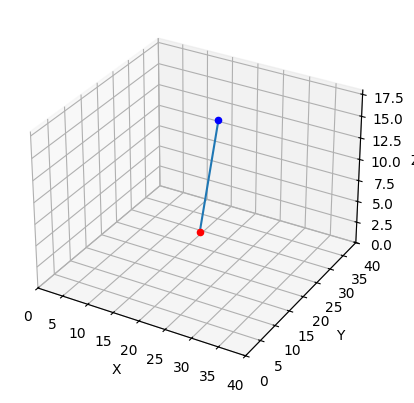

In [121]:
import matplotlib.pyplot as plt
import numpy as np
ind = 1
# ax = plt.figure().add_subplot(projection='3d')

fig, ax = plt.subplots(subplot_kw=dict(projection='3d'))

# out[ind,0:2]
ax.scatter(out[ind,0]/1e3,out[ind,1]/1e3,out[ind,2]/1e3,label='Final point',marker = 'o', color = 'blue')
ax.scatter(out[ind,3]/1e3,out[ind,4]/1e3,out[ind,5]/1e3,label='Origin point',marker = 'o', color = 'red')
ax.plot([out[ind,0]/1e3,out[ind,3]/1e3],[out[ind,1]/1e3,out[ind,4]/1e3],[out[ind,2]/1e3,out[ind,5]/1e3])

# Plot scatterplot data (20 2D points per colour) on the x and z axes.
# colors = ('r', 'g', 'b', 'k')



# # Make legend, set axes limits and labels
# ax.legend()
ax.set_xlim(0, 40)
ax.set_ylim(0, 40)
ax.set_zlim(0, 18)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Customize the view angle so it's easier to see that the scatter points lie
# on the plane y=0
# ax.view_init(elev=20., azim=-35, roll=0)

plt.show()

In [128]:
out[ind,:]

array([18651.19504783, 28655.5510983 , 14302.79124001, 20000.20272178,
       20002.06152521,  4002.49817007, 13523.55373789])

In [138]:
# x,y,z = out[ind,3:6]/1e3

dx = out[ind,0] - out[ind,3]
dy = out[ind,1] - out[ind,4]
dz = out[ind,2] - out[ind,5]
x,y,z = dx/1e3,dy/1e3,dz/1e3
print([x,y,z])
azi = np.arctan2(y,x)
zeni=np.arctan(((x**2 + y**2)**(1/2))/z)
print(math.degrees(azi))
print(math.degrees(zeni))

[-1.3490076739434953, 8.653489573086608, 10.300293069937815]
98.86062129229785
40.37344467567842


In [174]:
#Querying which photons were absorbed
dist = []
absorbed_indices = []
for i in np.arange(len(out)):
    point = masktree.query([out[i,2],out[i,1],out[i,0]])
    if point[0] <= 1100.:
        absorbed_indices.append(i)
    dist.append(point[0])    
dist = np.array(dist)

In [185]:
zp = list(flatten((dist > 1100.)))

# Generate some test data
x = out[zp,0]/1e3
y = out[zp,1]/1e3

In [205]:
data['XE']

<xarray.DataArray 'XE' (XE: 321)>
array([    0.,   125.,   250., ..., 39750., 39875., 40000.], dtype=float32)
Coordinates:
  * XE       (XE) float32 0.0 125.0 250.0 375.0 ... 3.975e+04 3.988e+04 4e+04
Attributes:
    type:       x1d
    long_name:  STAGGERED GRID POSITION IN X
    units:      meters
    index:      2
    posdef:     -1
    istag:      1
    jstag:      0
    kstag:      0
    dyntype:    -1
    phytype:    -1
    buotype:    0
    basedim:    0

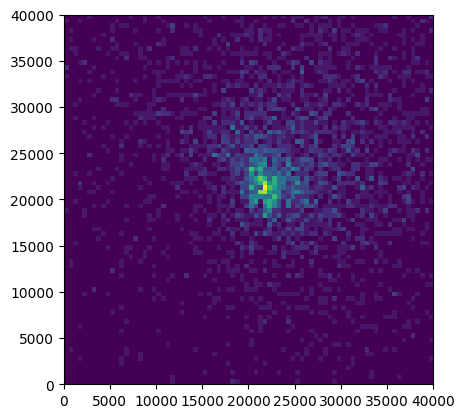

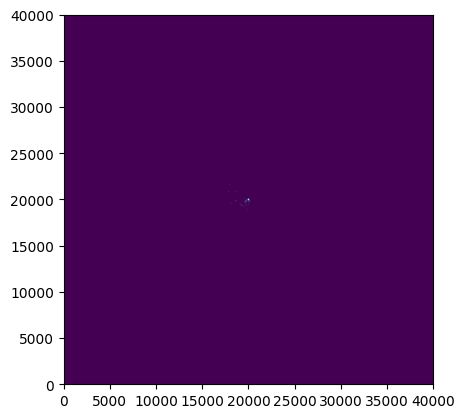

In [213]:
#creates 2 heatmaps, one of absorption and one of emission (exiting the cloud)



#EMITTED
outgrid = np.zeros([len(data['XC'])])
# grid_z2 = griddata(out[zp,0]/1e3,out[zp,1]/1e3, values, (grid_x, grid_y), method='cubic')
import numpy as np
import numpy.random
import matplotlib.pyplot as plt
# zp = list(flatten(np.where((dist > 1100.))))
zp = list(flatten((dist > 1100.)))

# Generate some test data
x = out[zp,0]
y = out[zp,1]

# heatmap, xedges, yedges = np.histogram2d(y, x, range=[[0, np.nanmax(data['XE'])], [0, np.nanmax(data['YE'])]],bins = [len(data['XC']),len(data['YC'])],density = True)
heatmap, xedges, yedges = np.histogram2d(y, x, range=[[0, np.nanmax(data['XE'])], [0, np.nanmax(data['YE'])]],bins = [80,80],density = False)

extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
# extent = [0, np.nanmax(data['XE']),0, np.nanmax(data['XE'])]

plt.clf()
plt.imshow(heatmap, extent=extent, origin='lower')
plt.show()

#ABSORBED
outgrid = np.zeros([len(data['XC']),len(data['XC'])])
zp = list(flatten((dist <= 1100.)))

# Generate some test data
x = out[zp,0]
y = out[zp,1]

heatmap5, xedges5, yedges5 = np.histogram2d(y, x, range=[[0, np.nanmax(data['XE'])], [0, np.nanmax(data['YE'])]],bins = [len(data['XC']),len(data['YC'])],density = True)
# extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
extent = [0, np.nanmax(data['XE']),0, np.nanmax(data['XE'])]

plt.clf()
plt.imshow(heatmap5, extent=extent, origin='lower')
plt.show()

In [219]:
len(xedges)

81

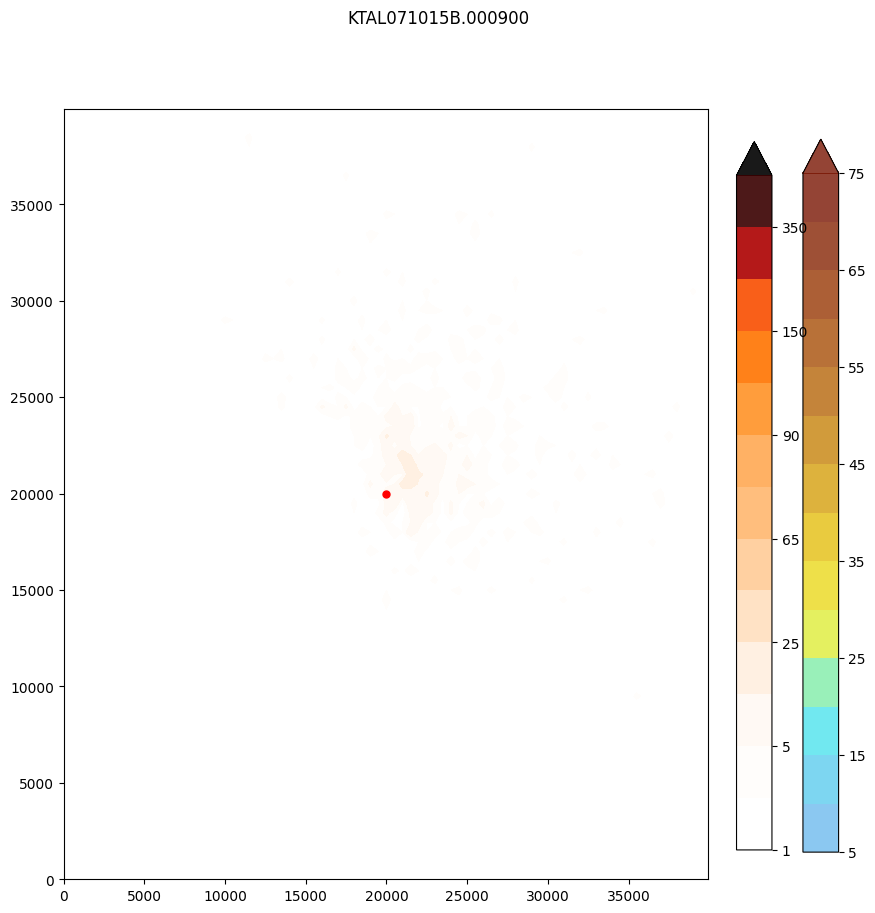

In [226]:
# out #= out5
# maxrefl = data['REFL_10CM'].max(axis=1)
frame = 0

ref_levels = [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75]
photon_levels = [1,2,5,10,25,40,65,80,90,125,150,200,350,500]
# photon_levels = [0.005,0.01,0.025,0.05,0.075,0.1,0.25,0.5,0.75,1,1.5,2,2.5,3,3.5,4,4.5,5]
# photon_levels = [0.1,0.25,0.5,0.75,1,1.5,2,2.5,3,3.5,4,4.5,5,6,7,8,9,10]

lambda_levels = [1,2,3,5,10,15,25,50,75,100,150,200,350,500,600,800,1000]
lambda_levels = [1,2,3,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,125,150,175,200]#25,50,75,100]#,350,500,600,800,1000]

fig, ax = plt.subplots(figsize=(10,10))

refl = maxrefl#maxrefl[frame,:,:]
fig.suptitle(str(end))
y_mesh, x_mesh = np.meshgrid(data['YC'],data['XC'])
ymesh2,xmesh2=np.meshgrid(xedges[0:80],yedges[0:80])
    
refplt = ax.contourf(y_mesh,x_mesh, refl, extend = 'max',levels = ref_levels,cmap='pyart_LangRainbow12',origin = 'lower', vmin=-24, vmax=72, alpha = 0.8)#,extent = [0,-10000,-20000,-10000])

fig.colorbar(refplt,fraction=0.046, pad=0.04)

# refplt2 = ax.contourf(ymesh2, xmesh2, heatmap5, extend = 'max',cmap='Greys_r',levels = photon_levels,origin = 'lower',vmin=1)#,extent = [0,-10000,-20000,-10000])
# refplt2 = ax.contourf(y_mesh, x_mesh, data['QC'].max(axis=1)[0,:,:]*1000, extend = 'max',cmap='Greys_r',alpha = 1.0,origin = 'lower',levels = lambda_levels)#,extent = [0,-10000,-20000,-10000])
refplt3 = ax.contourf(ymesh2, xmesh2, heatmap, extend = 'max',cmap='gist_heat_r',levels = photon_levels,alpha=0.9,origin = 'lower',vmin=1)#,extent = [0,-10000,-20000,-10000])
# refplt2 = ax.contourf(y_mesh, x_mesh, LAMreshape, extend = 'max',cmap='Greys_r',alpha = 1.0,origin = 'lower',levels = lambda_levels)#,extent = [0,-10000,-20000,-10000])


# test = (np.reshape(LAM_arr,[160,320,320]))
# LAMreshape = test[32,:,:]
# mask = np.where(LAMreshape < 200)
# pt2 = ax.scatter(data['YC'][mask[1]],data['XC'][mask[0]],marker = '*', color = 'black')

# mask = np.where(LAMreshape < 15)
# # pt2 = ax.scatter(data['YC'][mask[1]],data['XC'][mask[0]],marker = '*', color = 'blue')
# fig.colorbar(refplt2,fraction=0.046, pad=0.04)
fig.colorbar(refplt3,fraction=0.05, pad=0.04)


pt2 = ax.scatter(20e3,20e3,marker = 'o' ,color = 'red',s = 25.0)

# ax.scatter(out[:,0], out[:,1], out[:,2])
# ax.set_xlim(0, 140)
# ax.set_ylim(0, 140)
# ax.set_zlim(18e3, 0.)
# plt.show()
# fig.suptitle('Light escaping the cloud (percentage)', fontsize=16,y=0.92)
# savedir = "/Users/kelcy/Documents/ABSTRACT:CONFERENCE/GLM_SCIENCE_2024/"
# fig.savefig(savedir+'Light_emitted_percentage_v2.pdf',format = 'pdf',dpi=1200)



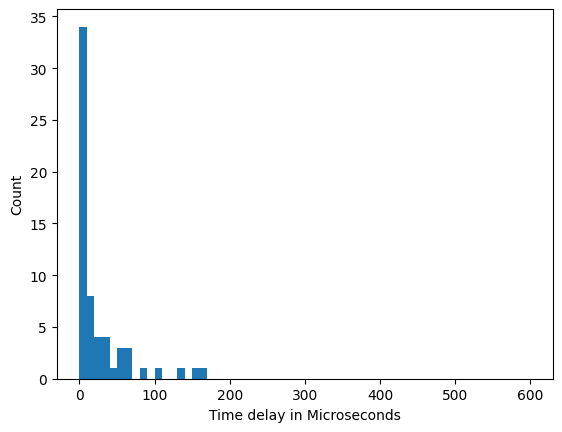

In [191]:
#Evaluate the time delay the photons experienced between emission and exiting the cloud or absorption
tdelay = out[:,-1]/constants.c
# tdelay*(10**(6))
import matplotlib.pyplot as plt
import numpy as np
fig, axs = plt.subplots(1)#, sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs.hist(tdelay[i]*(10**(6)),bins = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,
                                  210,220,230,240,250,260,270,280,290,300,310,320,330,340,350,360,370,380,390,400,
                                  410,420,430,440,450,460,470,480,490,500,510,520,530,540,550,560,570,580,590,600])
# axs[1].hist(dist2, bins=n_bins)
axs.set_xlabel('Time delay in Microseconds')
axs.set_ylabel('Count')

plt.show()


# plt.hist(tdelay*(10**(6)),bins = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,
#                                   210,220,230,240,250,260,270,280,290,300,310,320,330,340,350,360,370,380,390,400,
#                                   410,420,430,440,450,460,470,480,490,500,510,520,530,540,550,560,570,580,590,600])
# plt.show() 

#Alternative version using plt.hist
# plt.hist(((out[:,-1]/constants.c)*1e6)
#          , bins = [1,5,10,20,30,40,50,75,100,125,150,175,200,225,250,275,300,325,350,400,450,475,500,
#                   525,550,575,600,625,650,675,700,725,750,775,800,825,850,875,900,925,950,975,1000,1100,1200,1300,1400,1500,1600,1700,1800,1900,2000])

In [ ]:
#Legacy code for looping, or wrapping the model runs. 
# #;@knb_mc_wrapper
# import pickle

# #def knb_mc_wrapper: 

# savedir = "/Users/kelcy/PYTHON/KNB_PYMC/"

# #;The profile used in simulating the microphysical environment
# #;The default is the homogeneous profile. Additional profiles may be substituted.
# profile = pickle.load(open("/Users/kelcy/PYTHON/KNB_PYMC/homo_profile.p","rb"))


# #;The origin array is the point location of the source. A point source is the default, however an array may be restored and iterated through. A sample call for the array is commented, and again, the default is a point souce and must be commented out if an array is used. Note, the units of origin array must be in the same units as the coordinates, in this case it is meters (m).
# #;restore, 'origin_array.sav'
# origin_array = readsav("/Users/kelcy/IDL/brunnerk_mcmodel_idl/origin_array.sav")
# origin_array = np.array(sav_data['origin_array'])
# # origin_array = [5e3,5e3,7e3] #;the position is the center of the cloudf
# # origin_array = np.reshape(origin_array,(1,3))

# #;the coordinates of the simulated cloud
# coordinates = [1e4, 0.,1e4, 0.,1.2e4, 2e3]

# #;Selecting the number of frames to be simulated over. The default is 1, but this may be modified if a new origin or array of origin points is introduced for each frame. This is largely beneficial for simulating a full lightning flash, as opposed to a single frame or point source. The frame may be as long as you wish, the frame time only becomes pertinent when creating the source points. I select (prior to the simulation) the source points falling within a GLM frame. A frame is arbitrary in this model, and you may simulate all the sources in one frame, or wish to step through and save individual files for each frame - which may be easier for post processing. The choice is yours!
# no_frames = 1
# #;path to dir
# #;path = ;string of path name here
# #;no_frames = filesearch(path,count = no_frames)


# #;;;;selecting the number of photons and the seeds for this simulation;;;;;
# #;1. Set the number of photons to simulate
# m = 1000 #;the number of photons to simulate

# #;2. Set the size of the seed array. This is dependant on the number of source points
# s = origin_array.shape
# seed_time = int(time.time())#;this may be fixed if desired
# rng = np.random.default_rng(seed = seed_time)
# seed = (rng.uniform(0,1,1)*100.*(np.arange(no_frames*s[0])+1) ).astype(int)
# seed = np.reshape(seed,(no_frames,len(seed)))
# pickle.dump(seed,open(savedir+'/seeds.p',"wb"))

# #;;Begin iterating over each frame in the flash, and further over each source point in each flash. The default is a single frame, but the structure is left in this wrapper program should you desire to process multiple frames. , feeding the cloud dimensions, source points, number photons, and microphysical profile into the Monte Carlo Model.

# for k in np.arange(no_frames):
#     array_large = [ ] #;array large is the final location of the photon.

# #;;iterating over the number of sources in a frame
#     for i in np.arange(s[0]):

# #;;Following program is to call the model, the inputs are the number of photons, seeds, coordinates of the cloud, and output array, an input source array, and the input microphysics.
# #;;
#         out = knb_mc_sim(m, SEEDER = seed[k,i], coords = coordinates, origin = origin_array[i,:], PROFILE_IN = profile)

#         if i == 0:
#             array_large = out 
#         else:
# #;compiling the consecutive arrays of photons should be there be multiple frames in a simulation.
#             array_large = np.vstack((array_large,out))



# #;the file name selected here is the frame number_source origin. 
# pickle.dump(array_large, open(savedir+'array_large'+str(k)+'_'+str((np.mean(origin_array[0][2]/1e3)).astype(int))+'.p',"wb"))